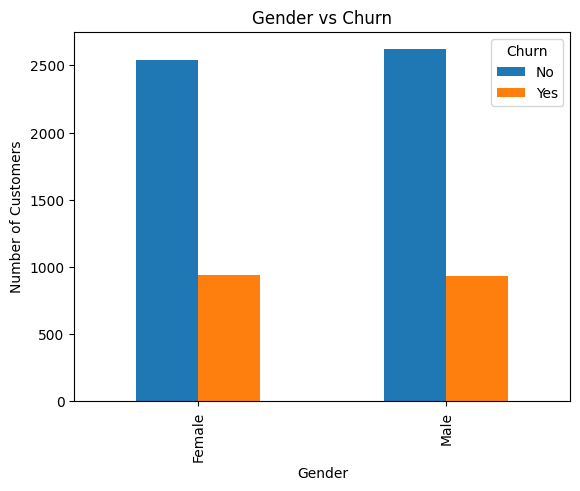

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove missing rows
df = df.dropna()

# Gender vs Churn
pd.crosstab(df["gender"], df["Churn"])

pd.crosstab(df["gender"], df["Churn"]).plot(kind="bar")

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [2]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


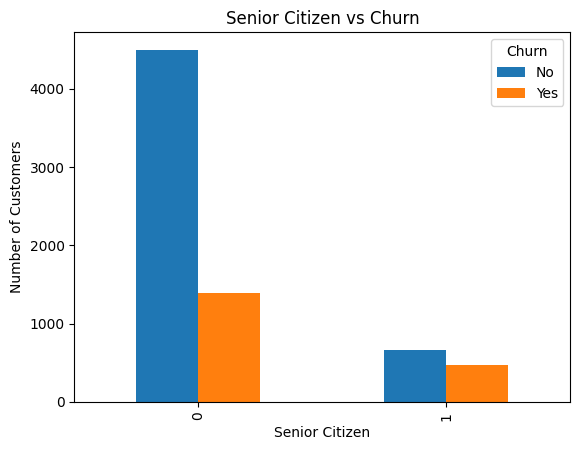

In [3]:
pd.crosstab(df["SeniorCitizen"], df["Churn"]).plot(kind="bar")

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

In [4]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [5]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


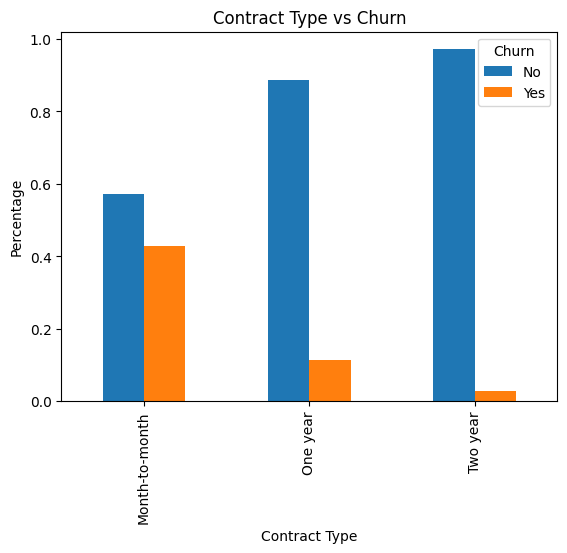

In [6]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.show()

In [7]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [9]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


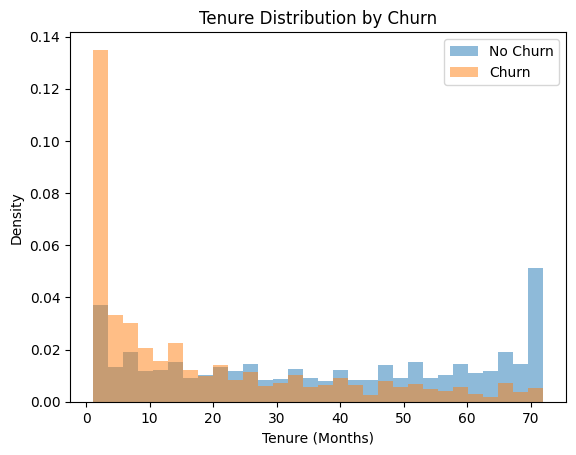

In [10]:
df[df["Churn"] == "No"]["tenure"].plot(kind="hist", alpha=0.5, label="No Churn", density=True, bins=30)
df[df["Churn"] == "Yes"]["tenure"].plot(kind="hist", alpha=0.5, label="Churn", density=True, bins=30)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [11]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


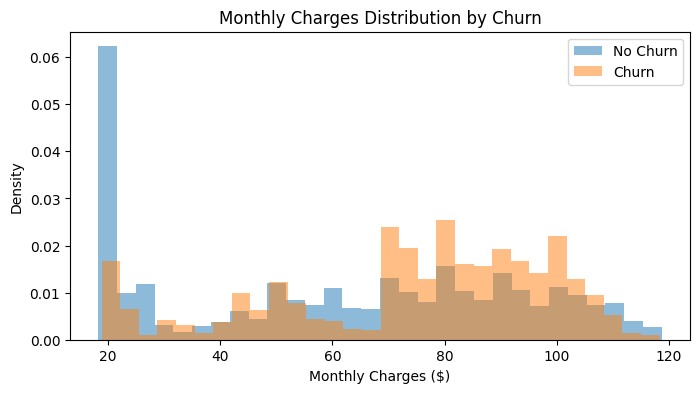

In [12]:
import matplotlib.pyplot as plt

# Create a figure with a specific size
plt.figure(figsize=(8, 4))

# Plot histogram for customers who did NOT churn (alpha makes it slightly transparent)
df[df["Churn"] == "No"]["MonthlyCharges"].plot(kind="hist", alpha=0.5, label="No Churn", density=True, bins=30)

# Plot histogram for customers who DID churn
df[df["Churn"] == "Yes"]["MonthlyCharges"].plot(kind="hist", alpha=0.5, label="Churn", density=True, bins=30)

# Add titles and labels
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


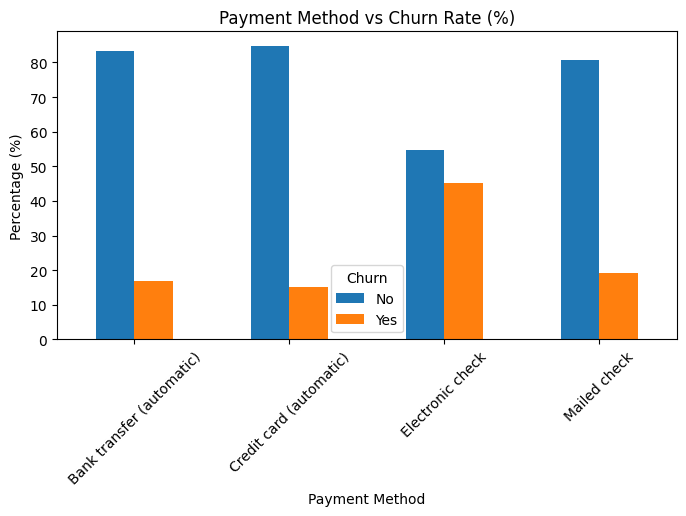

In [13]:
# Step 1: Get percentage breakdown of Churn by Payment Method
payment_crosstab = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
print(payment_crosstab)

# Step 2: Plot the percentage comparison using Matplotlib
payment_crosstab.plot(kind="bar", figsize=(8, 4))
plt.title("Payment Method vs Churn Rate (%)")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


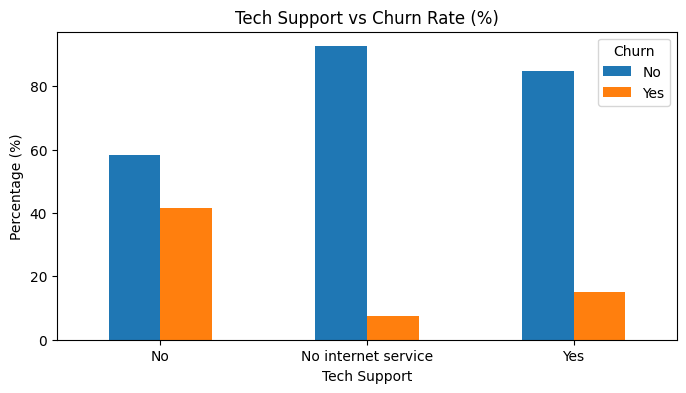

In [14]:
# Step 1: Crosstab percentage calculation for TechSupport vs Churn
tech_support_ct = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100
print(tech_support_ct)

# Step 2: Plot bar chart
tech_support_ct.plot(kind="bar", figsize=(8, 4))
plt.title("Tech Support vs Churn Rate (%)")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()